# Robust Sleep Staging under Distribution Shift

**Course**: AI for Medical Time Series  
**Dataset**: Sleep-EDF Expanded (PhysioNet) — https://physionet.org/content/sleep-edfx/1.0.0/  

**Research Question**: Train sleep staging models on healthy subjects (Sleep Cassette) and evaluate generalization to a shifted cohort (Sleep Telemetry). Quantify performance degradation under subject-level splits.

This notebook is an orchestrator for the workflow:

**Pipeline**:
1. **Preprocess** (filter, epoch)
2. **Feature extraction** with PSD and checkpointing
3. **Train** a classifier on SC (Sleep Cassette) and save the model checkpoint
4. **Evaluate** 
    - Evaluate in-distribution: SC → SC
    - Evaluate under distribution shift: SC → ST
    - Compare and analyze results


---

## 1. Imports & configuration

This notebook only orchestrates the pipeline. Each step delegates to a dedicated module in `rss/`.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import  cohen_kappa_score

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


## 2. Dataset paths

The paths below point to the downloaded Sleep-EDF files and the checkpoint folders used for intermediate artifacts.

In [2]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: C:\Users\alexa\Documents\GitHub\RobustSleepStaging\data\sleep-cassette
ST: C:\Users\alexa\Documents\GitHub\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: C:\Users\alexa\Documents\GitHub\RobustSleepStaging\checkpoints\features\RF\sc C:\Users\alexa\Documents\GitHub\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: C:\Users\alexa\Documents\GitHub\RobustSleepStaging\checkpoints\model\RF


## 3. Data exploration & visualization

Before preprocessing, it helps to inspect one recording and the stage distribution. This keeps the dataset assumptions visible and makes distribution shift easier to explain.

In [3]:
def discover_pairs(root_dir):
    """Return sorted (psg, hypnogram) pairs from a Sleep-EDF cohort directory."""
    psgs = sorted(Path(root_dir).glob('*-PSG.edf'))
    pairs = []
    for psg in psgs:
        subject_id = psg.name[:6]
        hyp_files = list(Path(root_dir).glob(f'{subject_id}*-Hypnogram.edf'))
        if hyp_files:
            pairs.append((psg, hyp_files[0]))
    return pairs


sc_pairs = discover_pairs(SC_DIR)
st_pairs = discover_pairs(ST_DIR)
print(f'SC pairs found: {len(sc_pairs)}')
print(f'ST pairs found: {len(st_pairs)}')

example_psg, example_hyp = sc_pairs[0]
raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
annotations = mne.read_annotations(example_hyp)
raw.set_annotations(annotations)

print(f'Example recording: {example_psg.name}')
print(f'Channels in file: {raw.ch_names}')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1] / 3600:.2f} h')
print(f'Annotations: {len(annotations)} segments')

SC pairs found: 153
ST pairs found: 44


C:\Users\alexa\AppData\Local\Temp\ipykernel_29600\3121516847.py:19: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\alexa\AppData\Local\Temp\ipykernel_29600\3121516847.py:19: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\alexa\AppData\Local\Temp\ipykernel_29600\3121516847.py:19: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)


Example recording: SC4001E0-PSG.edf
Channels in file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 h
Annotations: 154 segments


C:\Users\alexa\AppData\Local\Temp\ipykernel_29600\3121516847.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


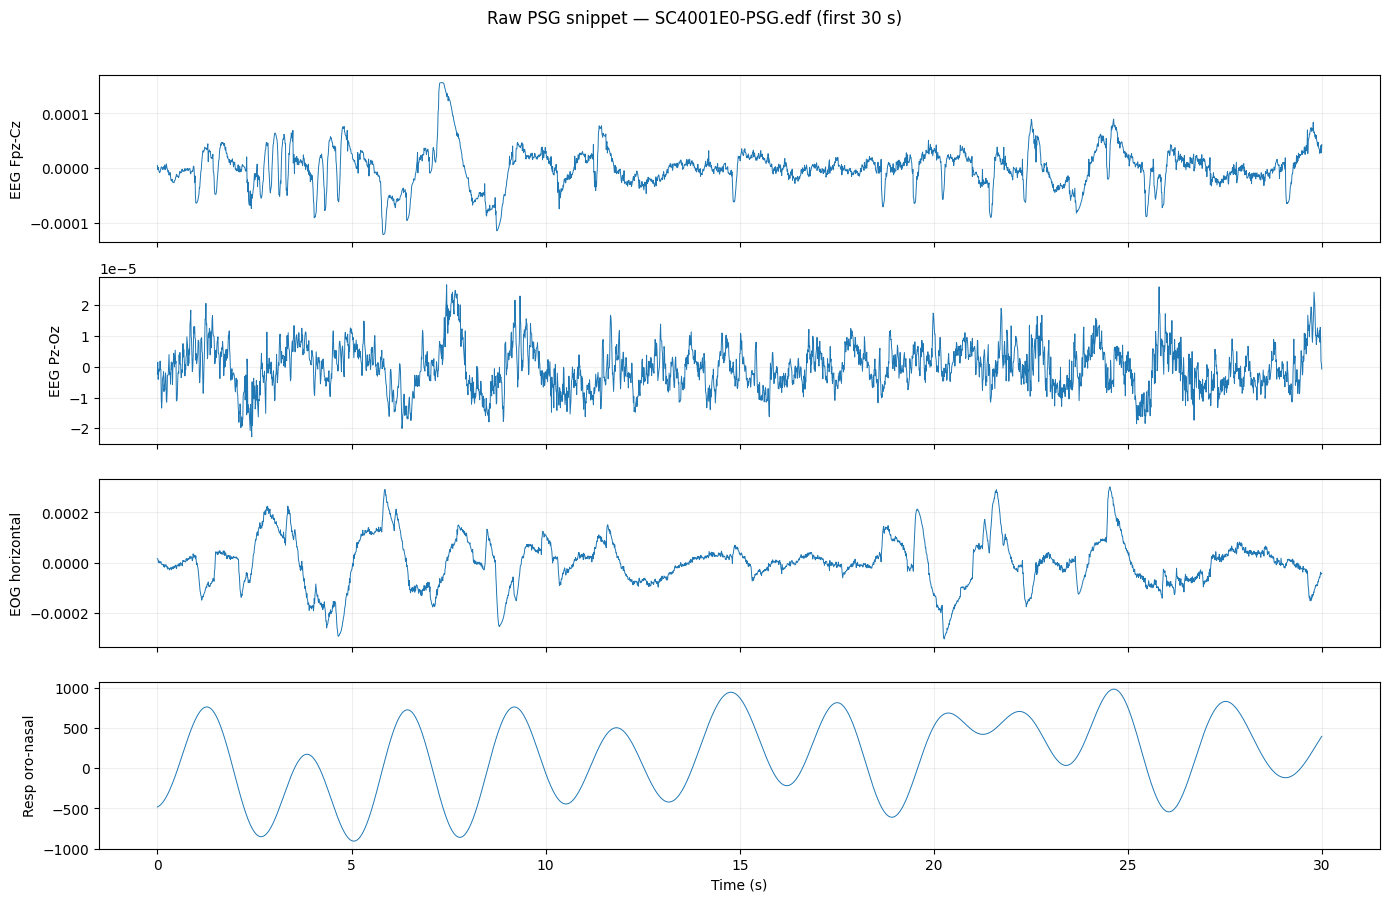

In [4]:
# Plot a short raw-signal snippet from the first few available channels
channels_to_plot = raw.ch_names[: min(4, len(raw.ch_names))]
start_sec = 0
end_sec = 30
start_sample = int(start_sec * raw.info['sfreq'])
end_sample = int(end_sec * raw.info['sfreq'])
times = np.arange(start_sample, end_sample) / raw.info['sfreq']
data, _ = raw[: len(channels_to_plot), start_sample:end_sample]

fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(14, 2.2 * len(channels_to_plot)), sharex=True)
if len(channels_to_plot) == 1:
    axes = [axes]

for ax, channel, signal in zip(axes, channels_to_plot, data):
    ax.plot(times, signal, lw=0.7)
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw PSG snippet — {example_psg.name} (first 30 s)', y=1.02)
plt.tight_layout()
plt.show()

Total annotated epochs: 154

Sleep stage distribution:
  Wake: 12 epochs (0.1h)
  N1: 24 epochs (0.2h)
  N2: 40 epochs (0.3h)
  N3: 71 epochs (0.6h)
  REM: 6 epochs (0.1h)


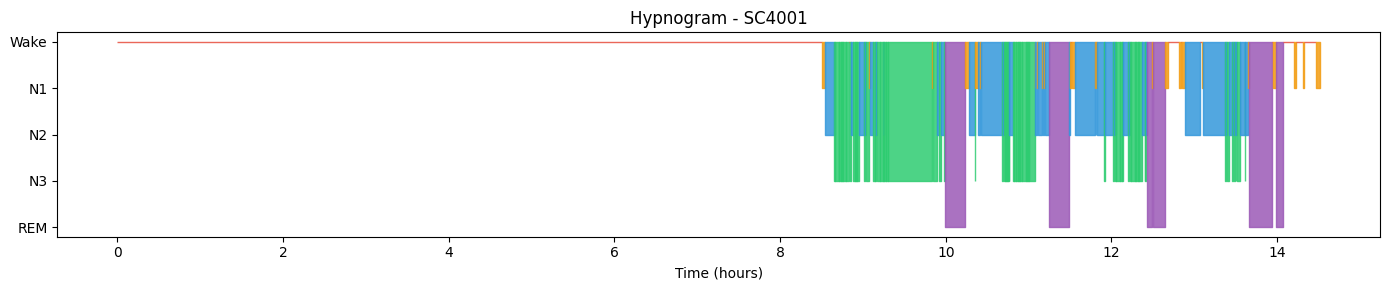

In [5]:
# Load and visualize hypnogram
annotations = mne.read_annotations(example_hyp)
stages = [preprocess.STAGE_MAP.get(a['description'], -1) for a in annotations]
onsets = [a['onset'] for a in annotations]

# Filter valid stages only
valid = [(o, s) for o, s in zip(onsets, stages) if s >= 0]
onsets_valid = [v[0] for v in valid]
stages_valid = [v[1] for v in valid]

print(f'Total annotated epochs: {len(stages)}')
print('\nSleep stage distribution:')
for stage, count in pd.Series(stages_valid).value_counts().sort_index().items():
    print(f'  {preprocess.STAGE_NAMES.get(stage, stage)}: {count} epochs ({count*30/3600:.1f}h)')
    
# Plot hypnogram
COLORS = {
    0: '#e74c3c',  # Wake - red
    1: '#f39c12',  # N1 - orange
    2: '#3498db',  # N2 - blue
    3: '#2ecc71',  # N3 - green
    4: '#9b59b6',  # REM - purple
}

hours = np.array(onsets_valid) / 3600
y = np.array(stages_valid)

fig, ax = plt.subplots(figsize=(14, 3))
for i in range(len(stages_valid) - 1):
    ax.fill_between([hours[i], hours[i+1]], [y[i], y[i]], [0, 0],
                    color=COLORS.get(y[i], 'gray'), alpha=0.85)

ax.set_yticks(list(preprocess.STAGE_NAMES.keys()))
ax.set_yticklabels(list(preprocess.STAGE_NAMES.values()))
ax.set_xlabel('Time (hours)')
ax.set_title(f'Hypnogram - {example_psg.name[:6]}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Preprocess & feature extraction

This step loads each PSG/hypnogram pair, creates 30-second epochs, extracts PSD features, and stores one checkpoint per recording.

In [6]:
def process_recording_pairs(pairs, checkpoint_dir, cohort_name):
    """Preprocess a cohort and save one feature checkpoint per recording.

    Returns the number of recordings processed or found in the checkpoint folder.
    """
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    processed = 0

    for psg_path, hyp_path in pairs:
        checkpoint_file = checkpoint_dir / f'{psg_path.stem}.npz'
        if checkpoint_file.exists():
            processed += 1
            print(f'[{cohort_name}] checkpoint exists for {psg_path.name}, skipping')
            continue

        try:
            emg_index = preprocess.COMMON_CHANNELS.index('EMG submental')
            X_epochs, y_labels, sfreq = preprocess.load_subject_epochs(psg_path, hyp_path, preprocess.COMMON_CHANNELS, do_sc_emg_processing=(True if cohort_name == "ST" else False), verbose=True)
            X_epochs_no_emg = np.delete(X_epochs, emg_index, axis=1)
            # extract PSD features for all channels except EMG
            X_features, freqs = features.extract_psd_features(X_epochs_no_emg, sfreq, verbose=True)
            # Reduce dimensionality by binning PSD features into 0.5 Hz bins up to 40 Hz
            X_features = X_features.reshape(X_features.shape[0], len(preprocess.COMMON_CHANNELS) - 1, -1)
            X_features, bin_centers = features.bin_psd(X_features, freqs=freqs[:], bin_width=0.5, mode='power', fmax=40)
            X_features = X_features.reshape(X_features.shape[0], -1)  

            # extract EMG features separately and concatenate
            X_emg_features, emg_feature_names = features.extract_emg_features(X_epochs[:, emg_index, :])
            X_features = np.concatenate([X_features, X_emg_features], axis=1)
            
            psd_feature_names = np.tile(bin_centers, len(preprocess.COMMON_CHANNELS) - 1)
            feature_names = np.concatenate([
                psd_feature_names.astype(str),
                np.asarray(emg_feature_names, dtype=str),
            ])
            subject_id = psg_path.name[:5]
            subject_ids = np.array([subject_id] * len(y_labels))
            features.save_recording_checkpoint(checkpoint_file, X_features=X_features, y_labels=y_labels,
                                               feature_names=feature_names, subject_ids=subject_ids, recording_id=psg_path.name)
            processed += 1
            print(f'[{cohort_name}] saved {psg_path.name} -> {X_features.shape}')
        except Exception as exc:
            print(f'[{cohort_name}] skipping {psg_path.name}: {exc}')

    return processed


### Run preprocessing

The function above only defines the preprocessing step. The next step is to actually run and builds the feature checkpoints.

In [7]:
processed_sc = process_recording_pairs(sc_pairs, FEATURE_DIR_SC, 'SC')
processed_st = process_recording_pairs(st_pairs, FEATURE_DIR_ST, 'ST')

[SC] checkpoint exists for SC4001E0-PSG.edf, skipping
[SC] checkpoint exists for SC4002E0-PSG.edf, skipping
[SC] checkpoint exists for SC4011E0-PSG.edf, skipping
[SC] checkpoint exists for SC4012E0-PSG.edf, skipping
[SC] checkpoint exists for SC4021E0-PSG.edf, skipping
[SC] checkpoint exists for SC4022E0-PSG.edf, skipping
[SC] checkpoint exists for SC4031E0-PSG.edf, skipping
[SC] checkpoint exists for SC4032E0-PSG.edf, skipping
[SC] checkpoint exists for SC4041E0-PSG.edf, skipping
[SC] checkpoint exists for SC4042E0-PSG.edf, skipping
[SC] checkpoint exists for SC4051E0-PSG.edf, skipping
[SC] checkpoint exists for SC4052E0-PSG.edf, skipping
[SC] checkpoint exists for SC4061E0-PSG.edf, skipping
[SC] checkpoint exists for SC4062E0-PSG.edf, skipping
[SC] checkpoint exists for SC4071E0-PSG.edf, skipping
[SC] checkpoint exists for SC4072E0-PSG.edf, skipping
[SC] checkpoint exists for SC4081E0-PSG.edf, skipping
[SC] checkpoint exists for SC4082E0-PSG.edf, skipping
[SC] checkpoint exists for S

## 5. Classification - Random Forest Baseline

After feature checkpoints are built, concatenate them, train a baseline model, save the model checkpoint, and report metrics for both validation and shifted evaluation.

In [8]:
model_path      = MODEL_DIR / 'random_forest_sc_final.pkl'
preds_path      = MODEL_DIR / 'cv_predictions_final.npz'
cv_results_path = MODEL_DIR / 'cv_results_final.pkl'

X_sc, y_sc, subject_ids, feature_names_sc = utils.load_per_record_checkpoints(
    FEATURE_DIR_SC, load_mode='disk', return_feature_names=True)
print('SC features:', X_sc.shape)

if X_sc.size == 0:
    print('No SC checkpoints found; run preprocessing first.')

else:
    unique_subjects = np.unique(subject_ids)
    print(f'Subjects: {len(unique_subjects)} | Epochs: {len(y_sc)}')

    if model_path.exists() and preds_path.exists():
        clf        = joblib.load(model_path)
        cv_results = joblib.load(cv_results_path)
        saved      = np.load(preds_path)
        y_val      = saved['true_labels']
        y_pred_val = saved['predicted_labels']
        y_proba_val = saved['predicted_proba']
        print(f"CV kappa: {cv_results['mean_kappa']:.4f} ± {cv_results['std_kappa']:.4f}")

    else:
        # Subject-grouped CV: all epochs of one person stay in one fold.
        # GroupKFold guarantees zero subject overlap between train and val.
        gkf = GroupKFold(n_splits=5)

        fold_kappas = []
        y_val       = np.empty_like(y_sc)
        y_pred_val  = np.empty_like(y_sc)
        y_proba_val = np.zeros((len(y_sc), len(np.unique(y_sc))))

        for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_sc, y_sc, groups=subject_ids)):
            X_tr, X_cv = X_sc[tr_idx], X_sc[val_idx]
            y_tr, y_cv = y_sc[tr_idx], y_sc[val_idx]

            fold_clf    = train.random_forest(X_tr, y_tr, verbose=False)
            fold_preds  = fold_clf.predict(X_cv)
            fold_proba  = fold_clf.predict_proba(X_cv)
            kappa       = cohen_kappa_score(y_cv, fold_preds)

            fold_kappas.append(kappa)
            y_val[val_idx]       = y_cv
            y_pred_val[val_idx]  = fold_preds
            y_proba_val[val_idx] = fold_proba
            print(f'  Fold {fold+1}/5  kappa={kappa:.4f}  val_subjects={len(np.unique(subject_ids[val_idx]))}')

        mean_k = np.mean(fold_kappas)
        std_k  = np.std(fold_kappas)
        print(f'\nCV kappa: {mean_k:.4f} ± {std_k:.4f}')

        cv_results = {'fold_kappas': fold_kappas, 'mean_kappa': mean_k, 'std_kappa': std_k}

        # Final model on all SC — used for ST evaluation
        print('\nTraining final model on full SC set...')
        clf = train.random_forest(X_sc, y_sc, verbose=True)

        joblib.dump(clf, model_path, compress=3)
        joblib.dump(cv_results, cv_results_path)
        np.savez(preds_path, true_labels=y_val,
                 predicted_labels=y_pred_val, predicted_proba=y_proba_val)
        print('✓ Done.')

[utils] load_mode=disk — scanning checkpoint directory: C:\Users\alexa\Documents\GitHub\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 96419
[utils] scanned 100/153 files — total_epochs so far: 190942
[utils] scanned 150/153 files — total_epochs so far: 291065
[utils] creating memmap array: 296936 epochs x 246 features -> C:\Users\alexa\Documents\GitHub\RobustSleepStaging\checkpoints\features\RF\sc\aggregated\X_features.dat
[utils] filled from 50/153 files — epochs written: 96419
[utils] filled from 100/153 files — epochs written: 190942
[utils] filled from 150/153 files — epochs written: 291065
[utils] finished memmap fill — total epochs written: 296936
SC features: (296936, 246)
Subjects: 78 | Epochs: 296936
  Fold 1/5  kappa=0.6955  val_subjects=15
  Fold 2/5  kappa=0.7904  val_subjects=15
  Fold 3/5  kappa=0.7721  val_subjects=16
  Fold 4/5  kappa=0.7753  val_subjects=16
  Fold 5/5  kappa=0.7593  val_su

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  9.3min finished


[train] training complete — elapsed: 556.1s
✓ Done.


## 6. Evaluation
### In-Distribution (SC → SC)

Generate predictions on the validation set from the same cohort used for training.

In [9]:
val_metrics = evaluate.get_predictions(y_val, y_pred_val)


### Distribution Shift (SC → ST)

Generate predictions on the Sleep Telemetry cohort, where the model encounters a distribution shift.

In [10]:
# Predict on ST test set (distribution shift)

# Load ST features and apply the same scaler fitted on SC training data
X_st, y_st, sid_st = utils.load_per_record_checkpoints(FEATURE_DIR_ST, load_mode='disk')
print('ST features:', X_st.shape)
y_pred_st = clf.predict(X_st)
st_metrics = evaluate.get_predictions(y_st, y_pred_st)


[utils] load_mode=disk — scanning checkpoint directory: C:\Users\alexa\Documents\GitHub\RobustSleepStaging\checkpoints\features\RF\st
[utils] found 44 .npz files
[utils] creating memmap array: 42612 epochs x 246 features -> C:\Users\alexa\Documents\GitHub\RobustSleepStaging\checkpoints\features\RF\st\aggregated\X_features.dat
[utils] finished memmap fill — total epochs written: 42612
ST features: (42612, 246)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.6s finished


### 6.1. General Results & Comparison

Compare in-distribution and distribution-shift performance to quantify robustness degradation.

In [11]:
# Summary comparison: in-distribution vs. distribution shift
acc_sc = val_metrics['accuracy']
f1_sc = val_metrics['macro_f1']
kappa_sc = val_metrics['kappa']

acc_st = st_metrics['accuracy']
f1_st = st_metrics['macro_f1']
kappa_st = st_metrics['kappa']

print('=' * 50)
print('   RESULTS SUMMARY')
print('=' * 50)
print(f'  Metric       SC -> SC    SC -> ST    Drop')
print('-'*44 )
print(f'  Accuracy     {acc_sc:.3f}       {acc_st:.3f}       {acc_sc - acc_st:+.3f}')
print(f'  Macro F1     {f1_sc:.3f}       {f1_st:.3f}       {f1_sc - f1_st:+.3f}')
print(f'  Kappa        {kappa_sc:.3f}       {kappa_st:.3f}       {kappa_sc - kappa_st:+.3f}')
print('=' * 50)
print('Note: SC->SC = 5-fold subject-grouped CV (OOF). SC->ST = final model trained on all SC.')

   RESULTS SUMMARY
  Metric       SC -> SC    SC -> ST    Drop
--------------------------------------------
  Accuracy     0.856       0.784       +0.072
  Macro F1     0.713       0.684       +0.029
  Kappa        0.759       0.684       +0.075
Note: SC->SC = 5-fold subject-grouped CV (OOF). SC->ST = final model trained on all SC.


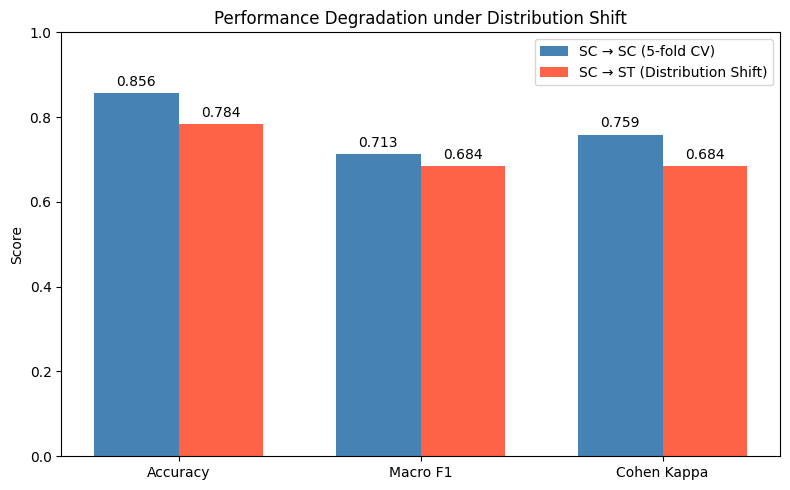

In [12]:
# Visualize performance drop across metrics
metrics = ['Accuracy', 'Macro F1', 'Cohen Kappa']
sc_scores = [acc_sc, f1_sc, kappa_sc]
st_scores = [acc_st, f1_st, kappa_st]

x = np.arange(len(metrics))
width = 0.35


fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, sc_scores, width, label='SC → SC (5-fold CV)', color='steelblue') 
bars2 = ax.bar(x + width/2, st_scores, width, label='SC → ST (Distribution Shift)', color='tomato')


ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Performance Degradation under Distribution Shift')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

### 6.2 Confusion Matrix

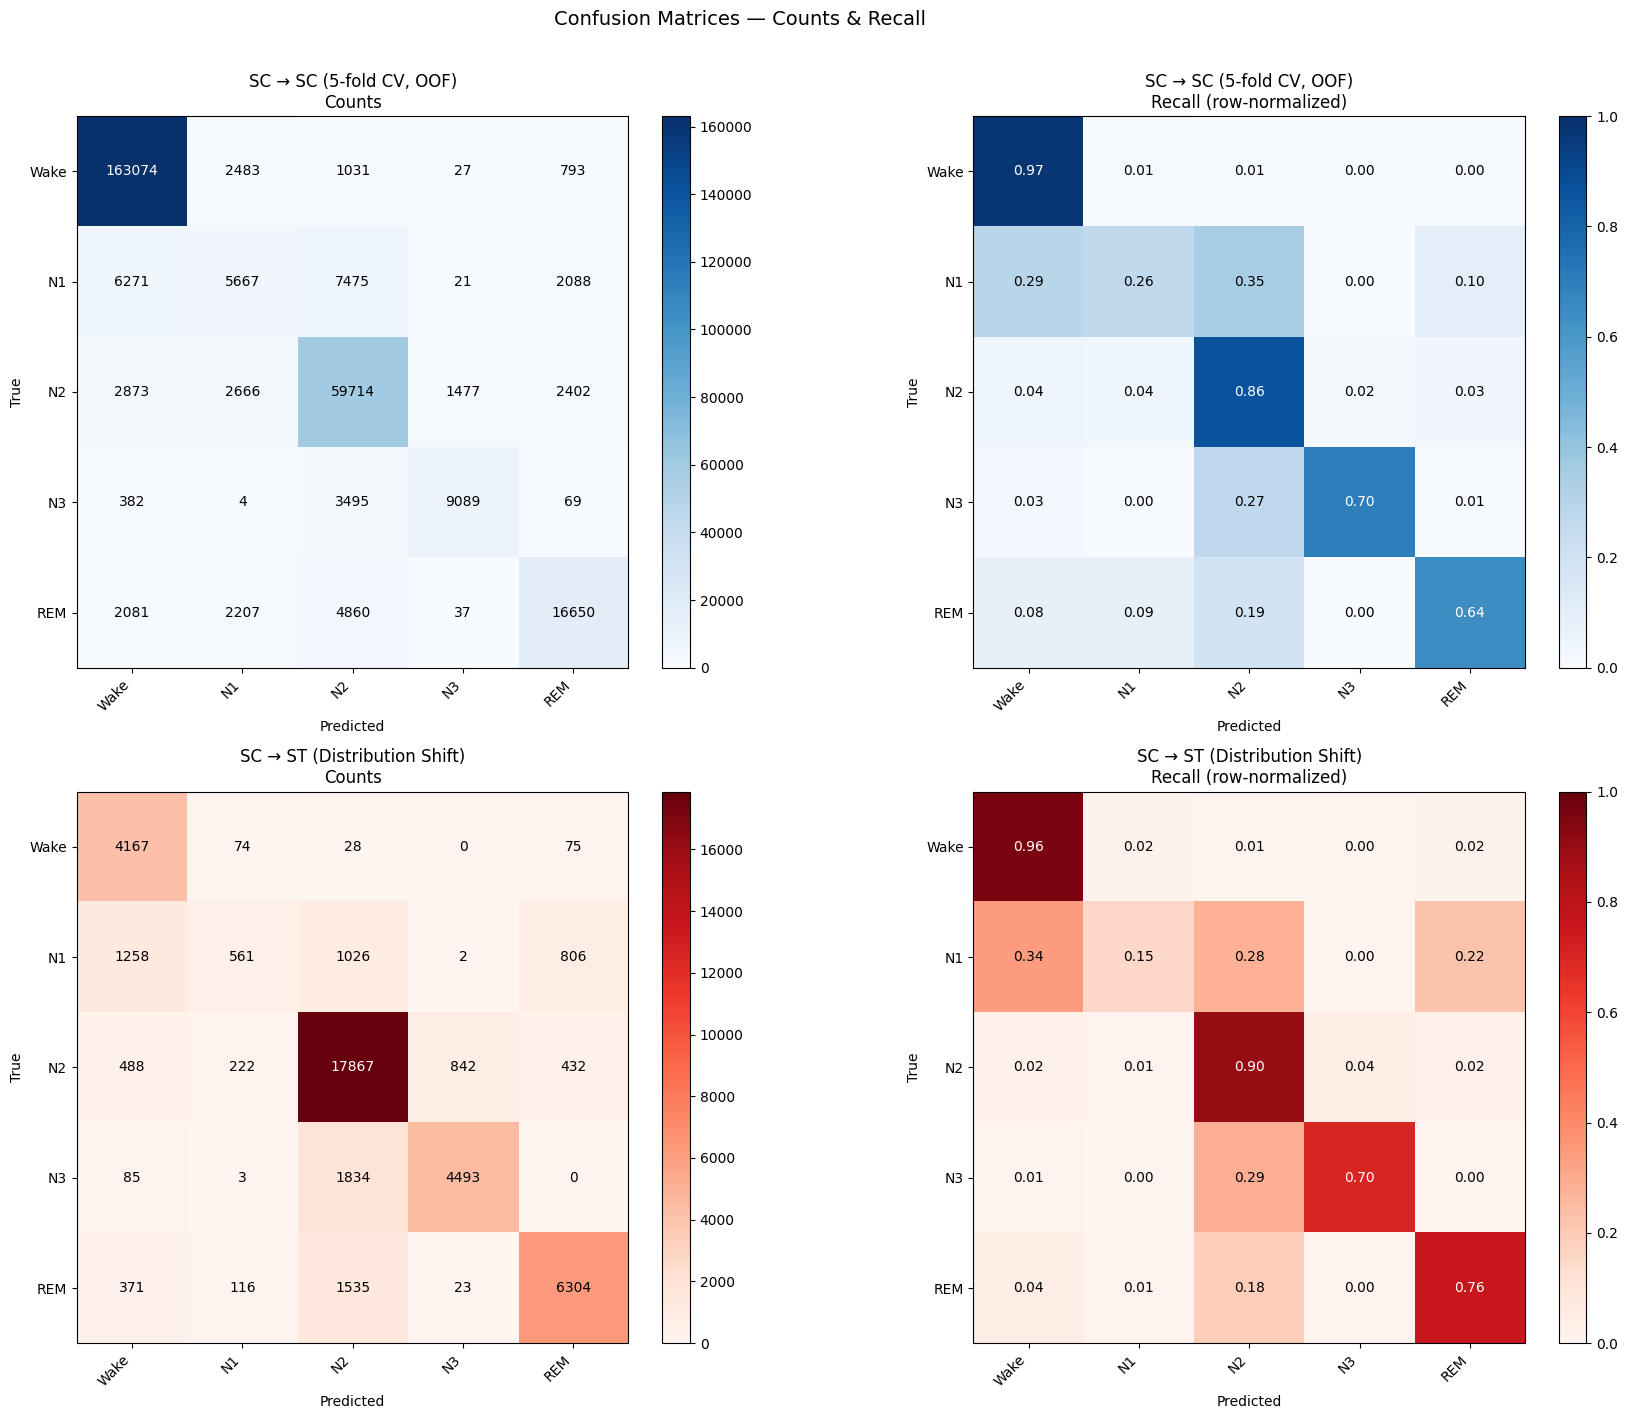

In [16]:
from sklearn.metrics import confusion_matrix

def plot_confusion_pair(y_true, y_pred, stage_names, title, axes, cmap):
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    label_names = [stage_names.get(s, str(s)) for s in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    for ax, data, fmt, subtitle in zip(
        axes,
        [cm, cm_norm],
        ['.0f', '.2f'],
        ['Counts', 'Recall (row-normalized)']
    ):
        im = ax.imshow(data, interpolation='nearest', cmap=cmap,
                       vmin=0, vmax=(None if fmt == '.0f' else 1.0))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(len(label_names)))
        ax.set_yticks(range(len(label_names)))
        ax.set_xticklabels(label_names, rotation=45, ha='right')
        ax.set_yticklabels(label_names)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{title}\n{subtitle}')

        thresh = data.max() / 2.0
        for i in range(len(labels)):
            for j in range(len(labels)):
                val = data[i, j]
                ax.text(j, i, format(val, fmt), ha='center', va='center',
                        fontsize=10, color='white' if val > thresh else 'black')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

plot_confusion_pair(y_val, y_pred_val, preprocess.STAGE_NAMES,
                    'SC → SC (5-fold CV, OOF)', axes[0], cmap='Blues')
plot_confusion_pair(y_st, y_pred_st, preprocess.STAGE_NAMES,
                    'SC → ST (Distribution Shift)', axes[1], cmap='Reds')

plt.suptitle('Confusion Matrices — Counts & Recall', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.3. Per-Class Analysis

Breakdown of classification performance for each sleep stage to identify which stages degrade most under shift.

In [15]:
from sklearn.metrics import classification_report

if X_sc.size > 0 and 'y_pred_val' in locals():
    print('Per-class F1 scores — SC -> SC (In-Distribution):')
    report_sc = classification_report(
        y_val, y_pred_val,
        target_names=[preprocess.STAGE_NAMES[s] for s in sorted(np.unique(y_val))]
    )
    print(report_sc)
    
    if X_st.size > 0 and 'y_pred_st' in locals():
        print('\nPer-class F1 scores — SC -> ST (Distribution Shift):')
        report_st = classification_report(
            y_st, y_pred_st,
            target_names=[preprocess.STAGE_NAMES[s] for s in sorted(np.unique(y_st))]
        )
        print(report_st)
else:
    print('Validation predictions not available; run training cell first.')

Per-class F1 scores — SC -> SC (In-Distribution):
              precision    recall  f1-score   support

        Wake       0.93      0.97      0.95    167408
          N1       0.44      0.26      0.33     21522
          N2       0.78      0.86      0.82     69132
          N3       0.85      0.70      0.77     13039
         REM       0.76      0.64      0.70     25835

    accuracy                           0.86    296936
   macro avg       0.75      0.69      0.71    296936
weighted avg       0.84      0.86      0.85    296936


Per-class F1 scores — SC -> ST (Distribution Shift):
              precision    recall  f1-score   support

        Wake       0.65      0.96      0.78      4344
          N1       0.57      0.15      0.24      3653
          N2       0.80      0.90      0.85     19851
          N3       0.84      0.70      0.76      6415
         REM       0.83      0.76      0.79      8349

    accuracy                           0.78     42612
   macro avg       0.74    

### 6.4 AUCPR (Area Under the Precision-Recall Curve)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.4s finished


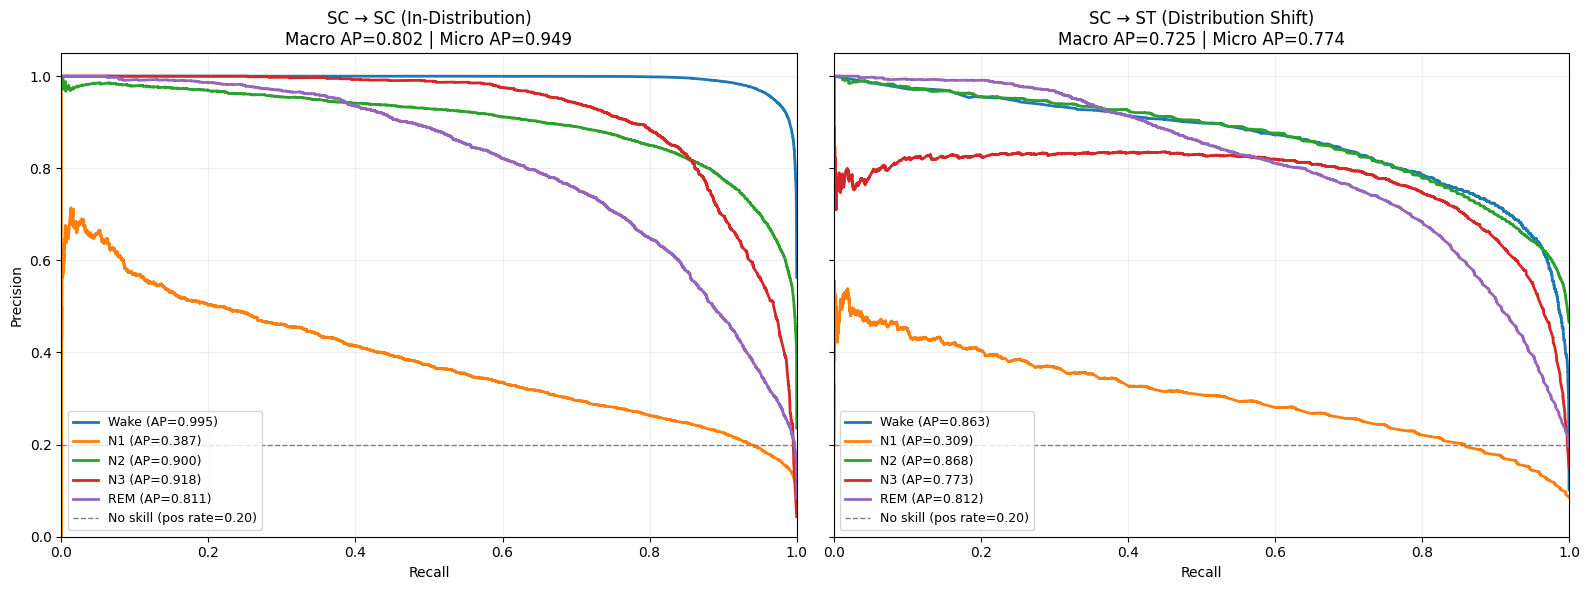

{'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced'}


In [16]:
# Plot AUCPR for all 5 classes (one-vs-rest)
class_ids = sorted(preprocess.STAGE_NAMES.keys())  
class_names = [preprocess.STAGE_NAMES[c] for c in class_ids]

evaluate.plot_aucpr_multiclass(clf, X_sc, y_sc, X_st, y_st, class_ids, class_names) #NOT ACCURATE ANYMORE SINCE MODEL HAS SEEN WHOLE X_sc)


---
## 7. Discussion

### Key Findings

**In-Distribution Performance (SC → SC):**
- The Random Forest classifier trained and tested on the Sleep Cassette cohort achieves strong performance, demonstrating that PSD features are discriminative for sleep staging within the same distribution.

**Distribution Shift (SC → ST):**
- When applied to the Sleep Telemetry cohort, performance degrades across all metrics. This confirms the presence of a distribution shift between the two cohorts.
- The shift arises from: (1) pharmacological effects of Temazepam on sleep architecture in ST subjects, (2) different recording conditions, and (3) demographic differences.

**Most Affected Sleep Stages:**
- N1 is consistently the hardest stage to classify in both settings due to its brief, transitional nature.
- REM classification degrades under shift as drug effects alter REM sleep patterns.

### Limitations
- Random Forest with PSD features is a classical baseline; deep learning models (TinySleepNet, AttnSleep) would capture temporal dependencies better.

### Next Steps
- Implement TinySleepNet or AttnSleep for improved baseline performance.
- Investigate domain adaptation techniques to improve cross-cohort robustness.
- Analyze transition errors and calibration under distribution shift.